# Density on particles

In [1]:
import gsw
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf

## Buoyancy by cluster (E / F)

Restrict the buoyancy calculation to particles belonging to one k-means pathway
group. The labels live in the clustering project's
`labeled_trajectories.parquet`, keyed by a global `trajectory_id`
(`= store_index * TRAJ_PER_STORE + local`). We pick a group, take a reproducible
random sample of its particles (group E has ~8M, so reading them all is
impractical), map each id back to its Zarr store + local index, and run the
**same `gsw` in-situ buoyancy recipe** as above on just those trajectories.

The result `clust` is an xarray Dataset (`trajectory`, `obs`) with `buoyancy`,
`sigma0`, `z`, `lat`, `lon` for the sampled cluster — so all the diagnostics
below can be run on it exactly like on a single store's `ds`.

In [11]:
# --- Select a k-means pathway group and sample its particles ----------------
import sys, pandas as pd
sys.path.insert(0, "/work/bk1450/b383184/Amazon/Mercator/notebooks/Analysis/"
                   "kmeans_analysis/kmean_analysis_30_180_stdZ_w")
import config as C   # gives LABELED_FILE, GROUP_NAMES, list_stores(), TRAJ_PER_STORE

GROUP        = "F"      # "E" or "F" (any name in C.GROUP_NAMES)
N_SAMPLE     = 20000     # trajectories to sample from the group (E has 8M -> sample)
RANDOM_STATE = 42

name2id = {v: k for k, v in C.GROUP_NAMES.items()}       # 'E'->5, 'F'->6, ...
gid     = name2id[GROUP]
lab     = pd.read_parquet(C.LABELED_FILE, columns=["trajectory_id", "cluster_group"])
grp     = lab[lab.cluster_group == gid]
sample  = grp.sample(min(N_SAMPLE, len(grp)), random_state=RANDOM_STATE)

tid = sample.trajectory_id.to_numpy()
sel = pd.DataFrame({"trajectory_id": tid,
                    "store_index":   tid // C.TRAJ_PER_STORE,
                    "local":         tid %  C.TRAJ_PER_STORE})
stores = C.list_stores()
print(f"group {GROUP} (id {gid}): {len(grp):,} particles total -> "
      f"sampling {len(sel):,} across {sel.store_index.nunique()} stores")

group F (id 6): 149,215 particles total -> sampling 20,000 across 771 stores


In [12]:
# --- In-situ buoyancy on the sampled particles (same gsw recipe as above) ----
# Each store is opened once, only the selected `local` trajectories are read, and
# the gsw buoyancy is computed per store; results are concatenated along
# trajectory. obs is aligned by an integer coordinate so stores with different
# obs lengths pad with NaN (join="outer"). Reads run in parallel (I/O-bound).
from joblib import Parallel, delayed
from tqdm import tqdm

def _buoyancy_store(si, g):
    ds = xr.open_zarr(stores[si]).isel(trajectory=g.local.to_numpy()).compute()
    ds = ds.assign_coords(obs=np.arange(ds.sizes["obs"]))
    p   = gsw.p_from_z(-ds.z, ds.lat)                 # z is positive-down depth
    SA  = gsw.SA_from_SP(ds.sal, p, ds.lon, ds.lat)
    CT  = gsw.CT_from_pt(SA, ds.temp)
    rho = gsw.rho(SA, CT, p)                          # in-situ density
    out = xr.Dataset({
        "buoyancy": (-9.81 * (rho - 1025) / 1025),
        "sigma0":   gsw.sigma0(SA, CT),
        "z":   ds.z, "lat": ds.lat, "lon": ds.lon, "time": ds.time,
    })
    out = out.assign_coords(trajectory_id=("trajectory",
              si * C.TRAJ_PER_STORE + g.local.to_numpy()))
    return out

parts = Parallel(n_jobs=16, backend="threading")(
    delayed(_buoyancy_store)(si, g) for si, g in tqdm(list(sel.groupby("store_index"))))
clust = xr.concat(parts, dim="trajectory", join="outer")
print(f"group {GROUP}: buoyancy dataset {dict(clust.sizes)}")
clust

100%|██████████| 771/771 [01:13<00:00, 10.45it/s]


group F: buoyancy dataset {'trajectory': 20000, 'obs': 925}


<xarray.Dataset> Size: 888MB
Dimensions:        (trajectory: 20000, obs: 925)
Coordinates:
  * obs            (obs) int64 7kB 0 1 2 3 4 5 6 ... 918 919 920 921 922 923 924
  * trajectory     (trajectory) int64 160kB 93 3303 5120 6797 ... 143 933 4283
    trajectory_id  (trajectory) int64 160kB 93 3303 325120 ... 16270933 16274283
Data variables:
    buoyancy       (trajectory, obs) float64 148MB 0.1509 0.1553 ... nan nan
    sigma0         (trajectory, obs) float64 148MB 9.224 8.767 8.293 ... nan nan
    z              (trajectory, obs) float64 148MB 2.376 2.259 2.137 ... nan nan
    lat            (trajectory, obs) float64 148MB 0.7087 0.7207 ... nan nan
    lon            (trajectory, obs) float64 148MB -49.61 -49.6 ... nan nan
    time           (trajectory, obs) datetime64[ns] 148MB 1993-01-06 ... NaT

group F: buoyancy mean=3.957e-02  std=5.083e-02  [m/s^2]


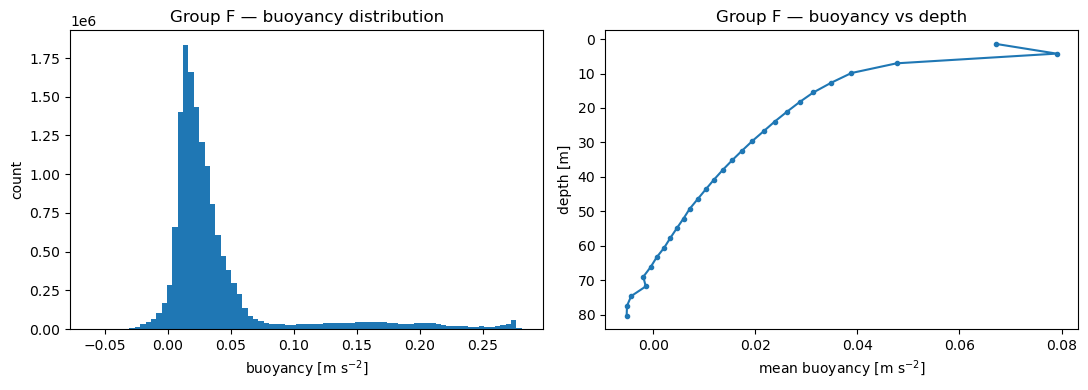

In [13]:
# --- Quick look: buoyancy distribution + mean vertical structure ------------
b = clust.buoyancy
bf, zf = b.values.ravel(), clust.z.values.ravel()
m = np.isfinite(bf) & np.isfinite(zf)
print(f"group {GROUP}: buoyancy mean={bf[m].mean():.3e}  std={bf[m].std():.3e}  [m/s^2]")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(bf[m], bins=80, color="C0")
ax[0].set_xlabel("buoyancy [m s$^{-2}$]"); ax[0].set_ylabel("count")
ax[0].set_title(f"Group {GROUP} — buoyancy distribution")

# mean buoyancy vs depth
zbin = np.linspace(0, np.nanpercentile(zf[m], 99), 30)
idx  = np.digitize(zf[m], zbin)
prof = np.array([bf[m][idx == k].mean() if np.any(idx == k) else np.nan
                 for k in range(1, len(zbin))])
ax[1].plot(prof, 0.5 * (zbin[1:] + zbin[:-1]), "-o", ms=3)
ax[1].invert_yaxis()
ax[1].set_xlabel("mean buoyancy [m s$^{-2}$]"); ax[1].set_ylabel("depth [m]")
ax[1].set_title(f"Group {GROUP} — buoyancy vs depth")
fig.tight_layout(); plt.show()

### σ₀ subduction diagnostic for the selected cluster

The same isopycnal-vs-diapycnal test as further down, but on `clust` (the sampled
pathway group) instead of a single store. **Δσ₀ ≈ 0** → the particle slides along
isopycnals (adiabatic subduction); **Δσ₀ > 0** → it densifies on the way down
(diapycnal transformation).

group F: 99 / 20000 particles reach > 200 m


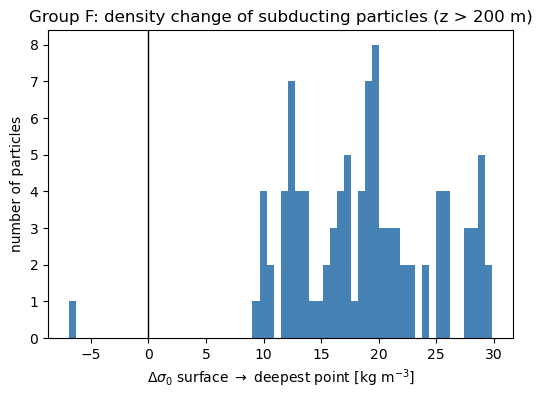

In [14]:
# --- Does potential density change as CLUSTER particles reach their deepest? --
# adiabatic (isopycnal) subduction -> dsigma ~ 0 ; diapycnal -> dsigma > 0.
# Operates on `clust` (obs 0 = release, near surface; z is positive-down depth).
zmax     = clust.z.max("obs")                       # deepest depth each particle reaches
deep_idx = clust.z.fillna(-np.inf).argmax("obs")    # obs index of that deepest point

sigma_start = clust.sigma0.isel(obs=0)              # start of track, near surface
sigma_deep  = clust.sigma0.isel(obs=deep_idx)       # at the deepest point
dsigma      = sigma_deep - sigma_start

z_thresh = 200.0                                    # m ; try 300 or 500 too
subd     = zmax > z_thresh
print(f"group {GROUP}: {int(subd.sum())} / {clust.sizes['trajectory']} "
      f"particles reach > {z_thresh:.0f} m")

vals = dsigma.where(subd).values.ravel()
vals = vals[np.isfinite(vals)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(vals, bins=60, color="steelblue")
ax.axvline(0, color="k", lw=1)
ax.set_xlabel(r"$\Delta\sigma_0$ surface $\rightarrow$ deepest point [kg m$^{-3}$]")
ax.set_ylabel("number of particles")
ax.set_title(f"Group {GROUP}: density change of subducting particles (z > {z_thresh:.0f} m)")
plt.show()

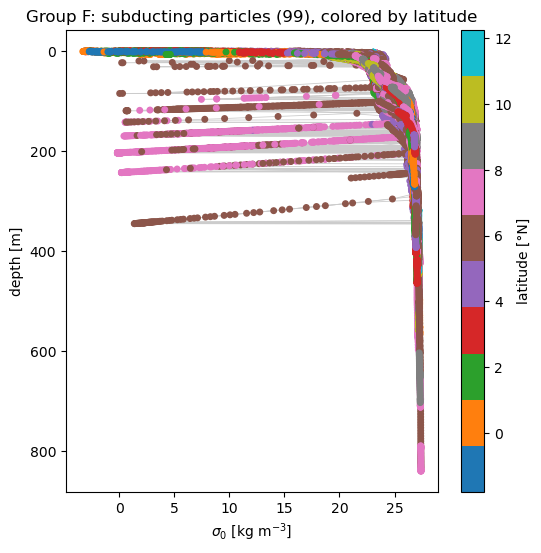

In [15]:
# --- Where (which latitude) do the CLUSTER's subducting particles sink? ------
# Path in (sigma0, depth) space, points colored by latitude.
#   vertical alignment (sigma0 constant) -> adiabatic / isopycnal subduction
#   drift toward denser water (sigma0 up) -> diapycnal densification
idx = np.where(subd.values)[0]

sig = clust.sigma0.isel(trajectory=idx).values.ravel()
zz  = clust.z.isel(trajectory=idx).values.ravel()
lat = clust.lat.isel(trajectory=idx).values.ravel()
m   = np.isfinite(sig) & np.isfinite(zz) & np.isfinite(lat)

fig, ax = plt.subplots(figsize=(6, 6))
# thin grey line per particle to keep the time-order of the path visible
# (capped at 400 tracks so a large cluster sample stays fast to draw)
for i in idx[:400]:
    ax.plot(clust.sigma0.isel(trajectory=i), clust.z.isel(trajectory=i),
            color="0.8", lw=0.6, zorder=1)
sc = ax.scatter(sig[m], zz[m], c=lat[m], cmap="tab10", s=16, zorder=2)
ax.invert_yaxis()                       # depth increases downward
cb = fig.colorbar(sc, ax=ax); cb.set_label("latitude [°N]")
ax.set_xlabel(r"$\sigma_0$ [kg m$^{-3}$]")
ax.set_ylabel("depth [m]")
ax.set_title(f"Group {GROUP}: subducting particles ({idx.size}), colored by latitude")
plt.show()

## Full cluster, per-month reductions (ALL particles)

The `clust` sample above is for interactive plots. To use **every** particle in a
group (E has ~8M) you cannot hold the full `(trajectory, obs)` paths in memory
(~350 GB). Instead we stream **store by store**, reduce each particle to a few
**scalars** (deepest depth `zmax`, `Δσ₀` surface→deepest, mean/min buoyancy),
tag it with its `release_month` (already in the labels), and accumulate a compact
per-particle table (8M rows × a few columns ≈ 200 MB). Then splitting by month is
a `groupby`.

This reads the whole E-subset once (heavy I/O — consider running it as a batch
job), and saves the reduced table to parquet so you never recompute it.

In [8]:
# --- ALL particles of a group: select every id + its release month ----------
FULL_GROUP = "E"          # group to process in full
Z_THRESH   = 200.0        # m ; a particle "subducts" if its zmax exceeds this
OUT_PARQUET = f"reduced_{FULL_GROUP}_permonth.parquet"   # saved per-particle table

gid_full = {v: k for k, v in C.GROUP_NAMES.items()}[FULL_GROUP]
labf = pd.read_parquet(C.LABELED_FILE,
                       columns=["trajectory_id", "cluster_group", "release_month",
                                "release_year", "status"])
grpf = labf[(labf.cluster_group == gid_full) & (labf.status != "early_loss")].copy()
grpf["store_index"] = grpf.trajectory_id // C.TRAJ_PER_STORE
grpf["local"]       = grpf.trajectory_id %  C.TRAJ_PER_STORE
print(f"group {FULL_GROUP}: {len(grpf):,} particles across "
      f"{grpf.store_index.nunique()} stores")

group E: 8,011,525 particles across 1616 stores


In [9]:
# --- Stream every store, reduce each particle to scalars, accumulate ---------
# Memory stays flat: each store yields only a small DataFrame (one row/particle),
# never the full (trajectory, obs) paths. Heavy I/O -> reads the whole E-subset
# once; run as a batch job if it's slow interactively. Cached to parquet after.
import os
from joblib import Parallel, delayed
from tqdm import tqdm

def _reduce_store(si, g):
    loc = g.local.to_numpy()
    ds  = xr.open_zarr(stores[si]).isel(trajectory=loc).compute()
    p   = gsw.p_from_z(-ds.z, ds.lat)
    SA  = gsw.SA_from_SP(ds.sal, p, ds.lon, ds.lat)
    CT  = gsw.CT_from_pt(SA, ds.temp)
    rho = gsw.rho(SA, CT, p)
    sig = gsw.sigma0(SA, CT)
    b   = -9.81 * (rho - 1025) / 1025
    deep_idx = ds.z.fillna(-np.inf).argmax("obs")          # obs of deepest point
    return pd.DataFrame({
        "trajectory_id": g.trajectory_id.to_numpy(),
        "release_month": g.release_month.to_numpy().astype("int8"),
        "release_year":  g.release_year.to_numpy().astype("int16"),
        "zmax":   ds.z.max("obs").values.astype("float32"),
        "dsigma": (sig.isel(obs=deep_idx) - sig.isel(obs=0)).values.astype("float32"),
        "b_mean": b.mean("obs").values.astype("float32"),
        "b_min":  b.min("obs").values.astype("float32"),
    })

if os.path.exists(OUT_PARQUET):
    red = pd.read_parquet(OUT_PARQUET)
    print(f"loaded cached {OUT_PARQUET}: {len(red):,} particles")
else:
    parts = Parallel(n_jobs=16, backend="threading")(
        delayed(_reduce_store)(si, g) for si, g in tqdm(list(grpf.groupby("store_index"))))
    red = pd.concat(parts, ignore_index=True)
    red["subd"] = red.zmax > Z_THRESH
    red.to_parquet(OUT_PARQUET, index=False)
    print(f"reduced {len(red):,} particles -> saved {OUT_PARQUET}")
red.head()

100%|██████████| 1616/1616 [04:34<00:00,  5.89it/s]


reduced 8,011,525 particles -> saved reduced_E_permonth.parquet


,trajectory_id,release_month,release_year,zmax,dsigma,b_mean,b_min,subd
0,1,1,1993,10.463024,-10.968072,0.236255,0.129484,False
1,5,1,1993,8.729996,-10.143588,0.236483,0.132941,False
2,15,1,1993,10.463024,-11.067396,0.236342,0.129454,False
3,16,1,1993,14.599932,-6.393188,0.236632,0.162590,False
4,20,1,1993,2.444570,-5.417476,0.256143,0.136245,False


group E — per release month:
          n  pct_subducting  mean_b  mean_dsigma_subd
Jan  767992            0.00    0.24         20.170000
Feb  756774            0.01    0.24         26.950001
Mar  847033            0.00    0.24         29.120001
Apr  859642            0.00    0.24         30.200001
May  946069            0.00    0.24         17.120001
Jun  820316            0.00    0.24         25.420000
Jul  734203            0.00    0.23         19.040001
Aug  529109            0.01    0.23         12.260000
Sep  353989            0.00    0.23         10.210000
Oct  364997            0.01    0.23          6.710000
Nov  406108            0.02    0.23         11.290000
Dec  625293            0.00    0.23               NaN


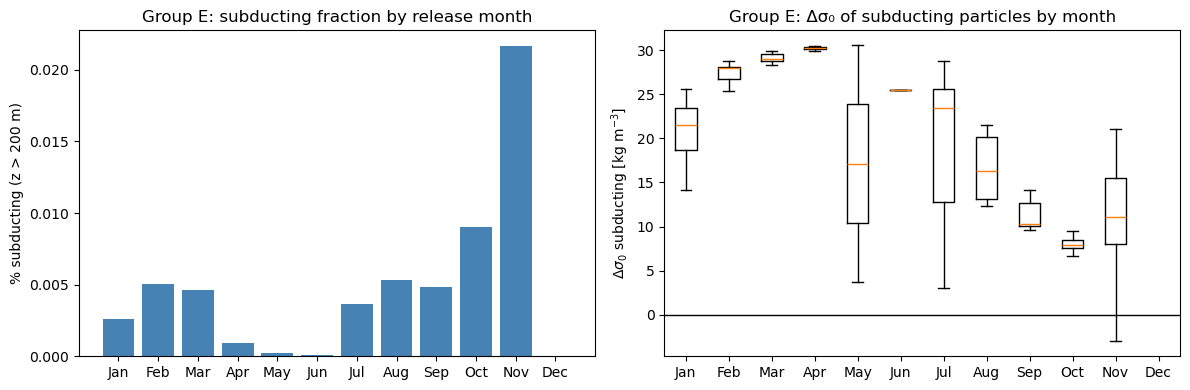

In [10]:
# --- Split by release month --------------------------------------------------
if "subd" not in red:               # in case a cached table predates the flag
    red["subd"] = red.zmax > Z_THRESH
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

by_month = pd.DataFrame({
    "n":                red.groupby("release_month").size(),
    "pct_subducting":   100 * red.groupby("release_month").subd.mean(),
    "mean_b":           red.groupby("release_month").b_mean.mean(),
}).reindex(range(1, 13))
# mean Delta-sigma0 over the SUBDUCTING particles only
by_month["mean_dsigma_subd"] = (red[red.subd].groupby("release_month").dsigma.mean()
                                .reindex(range(1, 13)))
by_month.index = [month_names[m-1] for m in by_month.index]
print(f"group {FULL_GROUP} — per release month:")
print(by_month.round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(by_month.index, by_month.pct_subducting, color="steelblue")
ax[0].set_ylabel(f"% subducting (z > {Z_THRESH:.0f} m)")
ax[0].set_title(f"Group {FULL_GROUP}: subducting fraction by release month")
# Delta-sigma0 distribution of subducting particles, per month (boxplot)
data = [red[(red.subd) & (red.release_month == m)].dsigma.values for m in range(1, 13)]
ax[1].boxplot(data, tick_labels=month_names, showfliers=False)
ax[1].axhline(0, color="k", lw=1)
ax[1].set_ylabel(r"$\Delta\sigma_0$ subducting [kg m$^{-3}$]")
ax[1].set_title(f"Group {FULL_GROUP}: Δσ₀ of subducting particles by month")
fig.tight_layout(); plt.show()

## Diagnostics — isopycnal (adiabatic) vs. diapycnal subduction

How does NBC/Amazon water reach ~500 m? Two mechanisms, distinguished by whether **potential density is conserved** as a particle sinks:

- **Δσ₀ ≈ 0** → the particle slides *along* tilting isopycnals — **adiabatic subduction** (retroflection / NBC-ring subduction, wind-driven downwelling). Water keeps its identity.
- **Δσ₀ > 0** → the particle gets denser on the way down — **diapycnal transformation** (surface buoyancy loss, then sinking; or interior mixing).

In-situ density can't tell these apart (it always rises with depth from compression), so we track **σ₀** along each trajectory.

In [33]:
# Potential density referenced to 250 dbar (mid-depth of the 0-500 m range).
# Same idea as sigma0, but the reference pressure sits closer to where the deep
# particles actually are, so it carries less thermobaric error over 0-500 m.
# sigma_250 = (gsw.rho(SA, CT, 250) - 1000).rename('sigma_250')

# # sanity check: over this depth range sigma0 and sigma_250 are nearly identical
# print('max |sigma0 - sigma_250| =',
#       float(np.abs(sigma0 - sigma_250).max()), 'kg/m^3')

3 / 10000 particles reach > 200 m


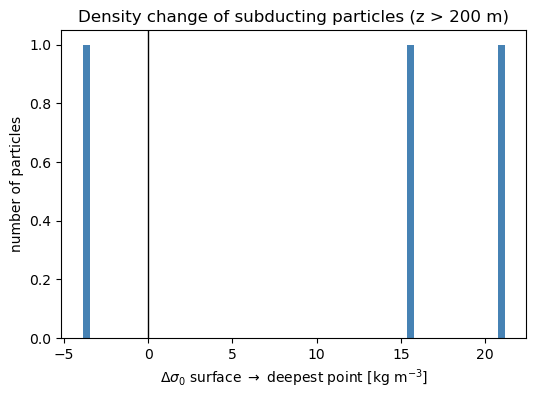

In [34]:
# --- Does potential density change as particles reach their deepest point? ---
# adiabatic (isopycnal) subduction -> dsigma ~ 0
# diapycnal transformation         -> dsigma  > 0  (water becomes denser)
zmax     = ds.z.max('obs')                        # deepest depth each particle reaches
deep_idx = ds.z.fillna(-np.inf).argmax('obs')     # obs index of that deepest point

sigma_start = sigma0.isel(obs=0)                   # start of track, near surface
sigma_deep  = sigma0.isel(obs=deep_idx)            # at the deepest point
dsigma      = sigma_deep - sigma_start

# focus on particles that actually subduct
z_thresh = 200.0                                   # m ; try 300 or 500 too
subd     = zmax > z_thresh
print(f'{int(subd.sum())} / {ds.sizes["trajectory"]} particles reach > {z_thresh:.0f} m')

vals = dsigma.where(subd).values.ravel()
vals = vals[np.isfinite(vals)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(vals, bins=60, color='steelblue')
ax.axvline(0, color='k', lw=1)
ax.set_xlabel(r'$\Delta\sigma_0$ surface $\rightarrow$ deepest point [kg m$^{-3}$]')
ax.set_ylabel('number of particles')
ax.set_title(f'Density change of subducting particles (z > {z_thresh:.0f} m)')
plt.show()